<h1>📊 Final Year Project (PFE) – Data Cleaning & Feature Engineering (Part 1)</h1>
<h2>Financial Analysis and Forecasting for an Engineering Consulting Firm</h2>

<hr>

<h3>⚙️ Project Overview</h3>
<p>
This notebook covers the <strong>data cleaning, validation, and feature engineering</strong> phases for sales datasets (2023–2025) from <em>an anonymized consulting client</em>. 
The goal is to prepare a unified, high-quality dataset for exploratory analysis, client categorization, and predictive modeling.
</p>

<hr>

<h3>🎯 Objectives</h3>
<ul>
  <li>Inspect raw datasets and identify missing or inconsistent values</li>
  <li>Clean and merge individual files into a single DataFrame</li>
  <li>Standardize columns, fix data types, and handle missing/negative values</li>
  <li>Engineer features: profit, payment method, return flags, and recalculate totals</li>
  <li>Prepare data for client categorization and ML modeling</li>
</ul>

<hr>

<h3>📌 Data Sources</h3>
<ul>
  <li>Sales records from 2023, 2024, and early 2025</li>
  <li>Extracted from anonymized financial invoices by a consulting engineering firm; this dataset is synthetic and mimics real-world data for analysis purposes.</li>
</ul>

<hr>

<h3>🗂️ Notebook Summary</h3>
<p>This notebook focuses on preparing the sales datasets for analysis and modeling. The main steps covered are:</p>
<ul>
  <li><strong>1. Imports and Data Loading:</strong> Import and inspect 2023–2025 sales data files.</li>
  <li><strong>2. Concatenate Data:</strong> Merge individual datasets into a single unified DataFrame.</li>
  <li><strong>3. Data Quality Check:</strong> Identify missing values, duplicates, and negative numbers.</li>
  <li><strong>4. Data Cleaning:</strong> Handle missing values, round floats, and rename columns to meaningful English names.</li>
  <li><strong>5. Data Validation:</strong> Ensure calculated fields like <code>Net_Sales</code> and <code>Total_Amount</code> are consistent.</li>
  <li><strong>6. Feature Engineering:</strong> Create additional variables such as <code>Profit</code>, <code>Payment_Method</code>, <code>Is_Return</code>, and normalize <code>Stamp_Duty</code>.</li>
  <li><strong>7. Modeling and Prediction:</strong> Create model feature engineering and model training.</li>

</ul>
<hr>

<strong>👨‍💻 Author:</strong> 
<a href="https://linkedin.com/in/asma-bouach">Asma Bouach</a><br>
<strong>📅 Project Period:</strong> Feb-May 2025<br>
<strong>🎓 Thesis Defense:</strong> July 2025<br>
<strong>🔄 Last Updated:</strong> November 2025 (Refactored with synthetic sata)
</p>

### 1. Imports and Data Loading

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from sklearn.metrics import (
    f1_score, matthews_corrcoef, roc_auc_score, make_scorer,
    classification_report, confusion_matrix, accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy import stats

import shap
import joblib
from joblib import dump

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

##### 1.1 Loading the data

In [3]:
df_2023 = pd.read_excel('../data/raw/sales_2023.xlsx')
df_2024 = pd.read_excel('../data/raw/sales_2024.xlsx')
df_2025 = pd.read_excel('../data/raw/sales_2025.xlsx')

##### 1.2 Initial data inspection

In [4]:
print("=== Data Shape ===")
print(f"2023 Dataset: {df_2023.shape}")
print(f"2024 Dataset: {df_2024.shape}")
print(f"2025 Dataset: {df_2025.shape}")

=== Data Shape ===
2023 Dataset: (9242, 11)
2024 Dataset: (9225, 11)
2025 Dataset: (8040, 11)


In [5]:
print("=== First Few Rows of 2023 Data ===")
display(df_2023.head())

print("\n=== First Few Rows of 2024 Data ===")
display(df_2024.head())

print("\n=== First Few Rows of 2025 Data ===")
display(df_2025.head())

=== First Few Rows of 2023 Data ===


,Code,Number,Date,Gross,Disc,Net,CostOfGoods,VAT,DutyStamp,Total,Category
0,C2404,OR2300000001,2023-01-01,19066.38,NaN,19066.38,8251.99,3622.61,1.00,22689.99,OR
1,C2592,OR2300000002,2023-01-01,14487.86,NaN,14487.86,8670.07,2752.69,1.00,17241.55,OR
2,C812,OR2300000003,2023-01-01,2015.65,NaN,2015.65,1670.28,382.97,1.00,2399.62,OR
3,C1839,RE2300000001,2023-01-01,-433.25,NaN,-433.25,NaN,-82.32,NaN,-515.57,RE
4,C2773,OR2300000004,2023-01-01,1531.69,NaN,1531.69,976.30,291.02,1.00,1823.71,OR



=== First Few Rows of 2024 Data ===


,Code,Number,Date,Gross,Disc,Net,CostOfGoods,VAT,DutyStamp,Total,Category
0,C2346,IC2400000001,2024-01-01,163.40,NaN,163.40,77.95,31.05,1.00,195.45,IC
1,C919,RE2400000001,2024-01-01,-196.84,NaN,-196.84,NaN,-37.40,NaN,-234.24,RE
2,C1392,OR2400000001,2024-01-01,1896.02,NaN,1896.02,847.27,360.24,1.00,2257.26,OR
3,C785,OR2400000002,2024-01-01,75438.45,NaN,75438.45,44378.21,14333.31,1.00,89772.76,OR
4,C971,OR2400000003,2024-01-01,5659.63,NaN,5659.63,2607.11,1075.33,NaN,6734.96,OR



=== First Few Rows of 2025 Data ===


,Code,Number,Date,Gross,Disc,Net,CostOfGoods,VAT,DutyStamp,Total,Category
0,C112,IC2500000001,2025-01-01,739.31,NaN,739.31,438.69,140.47,1.00,880.78,IC
1,C1318,OR2500000001,2025-01-01,2113.22,NaN,2113.22,1526.89,401.51,NaN,2514.73,OR
2,C829,OR2500000002,2025-01-01,1217.42,NaN,1217.42,583.47,231.31,1.00,1449.73,OR
3,C1591,OR2500000003,2025-01-01,2081.08,NaN,2081.08,884.38,395.40,1.00,2477.48,OR
4,C881,OR2500000004,2025-01-01,54.80,NaN,54.80,26.89,10.41,NaN,65.21,OR


In [6]:
print("=== Data Types of 2023 ===")
print(df_2023.info())
print("\n=== Data Types of 2024 ===")
print(df_2024.info())
print("\n=== Data Types of 2025 ===")
print(df_2025.info())

=== Data Types of 2023 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9242 entries, 0 to 9241
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Code         9242 non-null   object        
 1   Number       9242 non-null   object        
 2   Date         9242 non-null   datetime64[ns]
 3   Gross        9242 non-null   float64       
 4   Disc         641 non-null    float64       
 5   Net          9242 non-null   float64       
 6   CostOfGoods  8665 non-null   float64       
 7   VAT          9242 non-null   float64       
 8   DutyStamp    7638 non-null   float64       
 9   Total        9242 non-null   float64       
 10  Category     9242 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 794.4+ KB
None

=== Data Types of 2024 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9225 entries, 0 to 9224
Data columns (total 11 columns):
 #   Column     

<br>
<hr>
<h4>📝 Summary: Load and Inspect Raw Datasets</h4>
<ul>
    <li><strong>Data Size:</strong> 2023 (9242 rows, 11 cols), 2024 (9225 rows, 11 cols), 2025 (8040 rows, 11 cols).</li>
</ul>


<h4>📊 Column Explanations</h4>
<ul>
    <li><strong>Code:</strong> Client code.</li>
    <li><strong>Number:</strong> Invoice number associated with the transaction.</li>
    <li><strong>Date:</strong> The date the invoice was issued.</li>
    <li><strong>Gross:</strong> Gross revenue before any discounts are applied.</li>
    <li><strong>Disc:</strong> Discount applied to the transaction.</li>
    <li><strong>Net:</strong> Net value excluding tax, calculated after applying the discount.</li>
    <li><strong>CostOfGoods :</strong> Cost of goods sold (COGS), which represents the material cost (not labor). This is the cost of the parts used for repairs.</li>
    <li><strong>VAT:</strong> Value-added tax (VAT) at 19%.</li>
    <li><strong>DutyStamp:</strong> Stamp duty, usually 1 TND, except for clients working with the governorate who do not pay this fee.</li>
    <li><strong>Total:</strong> Net revenue including VAT and stamp duty.</li>
    <li><strong>Category:</strong> The type or nature of the invoice, typically indicating the category of client (State, private, insurrance agencies, etc.).</li>
</ul>
<hr>

### 2.  Concatenate Data


##### Concat all the 3 dataframes

In [7]:
# df_2023, df_2024, df_2025

# Combine them using pd.concat
df_combined = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

In [8]:
df_combined.head(10)

,Code,Number,Date,Gross,Disc,Net,CostOfGoods,VAT,DutyStamp,Total,Category
0,C2404,OR2300000001,2023-01-01,19066.38,NaN,19066.38,8251.99,3622.61,1.00,22689.99,OR
1,C2592,OR2300000002,2023-01-01,14487.86,NaN,14487.86,8670.07,2752.69,1.00,17241.55,OR
2,C812,OR2300000003,2023-01-01,2015.65,NaN,2015.65,1670.28,382.97,1.00,2399.62,OR
3,C1839,RE2300000001,2023-01-01,-433.25,NaN,-433.25,NaN,-82.32,NaN,-515.57,RE
4,C2773,OR2300000004,2023-01-01,1531.69,NaN,1531.69,976.30,291.02,1.00,1823.71,OR
5,C2264,OR2300000005,2023-01-01,1746.59,NaN,1746.59,1084.43,331.85,1.00,2079.44,OR
6,C1565,OR2300000006,2023-01-01,1453.98,16.95,1437.03,836.33,273.04,1.00,1711.07,OR
7,C1760,OR2300000007,2023-01-02,704.85,NaN,704.85,201.80,133.92,1.00,839.77,OR
8,C576,OR2300000008,2023-01-02,425.08,NaN,425.08,244.10,80.76,1.00,506.84,OR
9,C470,RE2300000002,2023-01-02,-4751.30,NaN,-4751.30,NaN,-902.75,NaN,-5654.05,RE


In [9]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26507 entries, 0 to 26506
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Code         26507 non-null  object        
 1   Number       26507 non-null  object        
 2   Date         26507 non-null  datetime64[ns]
 3   Gross        26507 non-null  float64       
 4   Disc         1807 non-null   float64       
 5   Net          26507 non-null  float64       
 6   CostOfGoods  24904 non-null  float64       
 7   VAT          26507 non-null  float64       
 8   DutyStamp    21950 non-null  float64       
 9   Total        26507 non-null  float64       
 10  Category     26507 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 2.2+ MB


<hr>
<h4>📝 Summary: Concatenate Data</h4>
<ul>
    <li><strong>Combined Dataset:</strong> The datasets from 2023, 2024, and 2025 were merged into a single DataFrame with 26,507 rows and 11 columns.</li>
    <li><strong>Missing Values:</strong> Some columns contain missing data, particularly 'Disc' (24,700 missing), 'CostOfGoods' (1,603 missing), and 'DutyStamp' (4,557 missing).</li>
</ul>
<hr>

### 3.  Data Quality Check

##### Inspect the combined data: Missing rows, duplicates, describe and report

In [10]:
#Check for all NaN values in each column
print("Missing values")
print(df_combined.isnull().sum())

Missing values
Code               0
Number             0
Date               0
Gross              0
Disc           24700
Net                0
CostOfGoods     1603
VAT                0
DutyStamp       4557
Total              0
Category           0
dtype: int64


<Axes: >

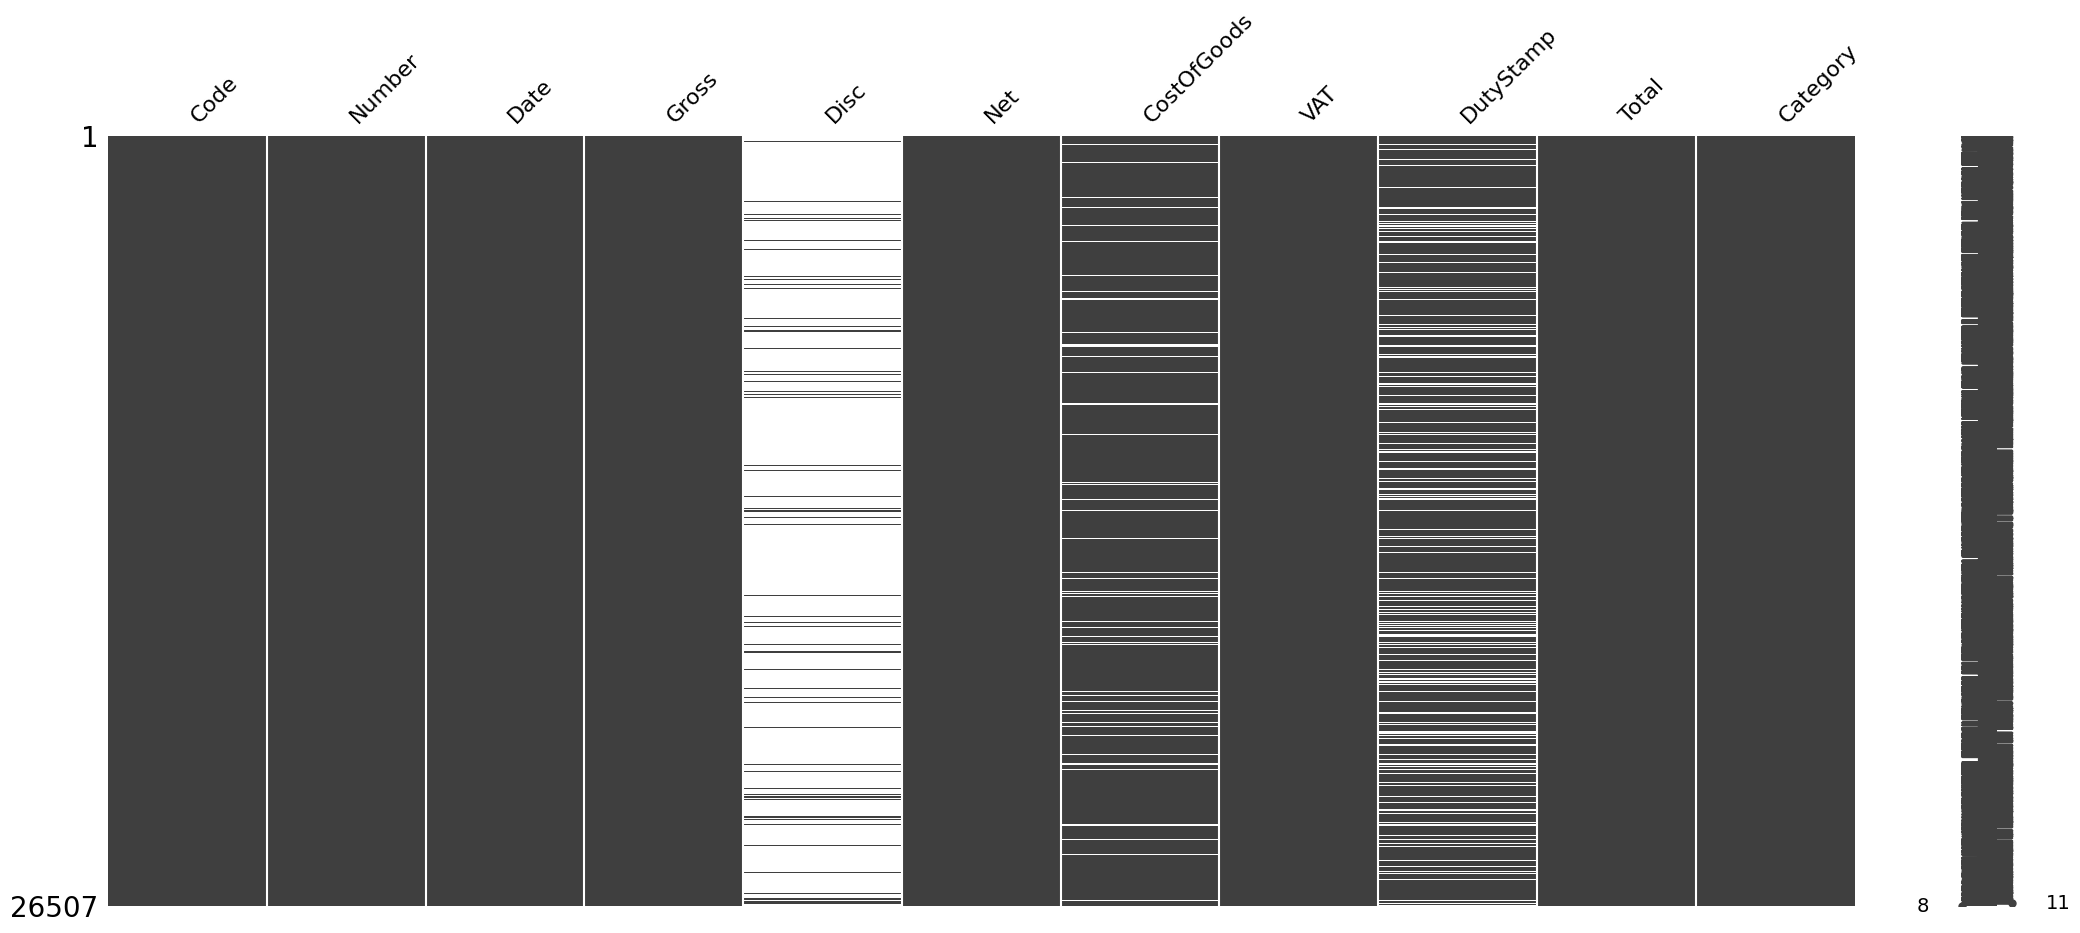

In [11]:
# Visualize missing patterns
msno.matrix(df_combined)  # Show missing data patterns

In [12]:
print("Duplicate rows")
dup_count = df_combined.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

Duplicate rows
Number of duplicate rows: 0


In [13]:
df_combined.describe()

,Date,Gross,Disc,Net,CostOfGoods,VAT,DutyStamp,Total
count,26507,26507.00,1807.00,26507.00,24904.00,26507.00,21950.00,26507.00
mean,2024-06-12 03:04:48.874636800,12341.71,282.85,12322.43,6349.11,2341.26,1.00,14664.51
min,2023-01-01 00:00:00,-281349.32,-4546.36,-281349.32,0.18,-53456.37,1.00,-334805.69
25%,2023-09-26 00:00:00,402.26,3.85,402.06,222.38,76.40,1.00,479.08
50%,2024-06-14 00:00:00,1817.45,21.47,1816.30,926.15,345.10,1.00,2162.40
75%,2025-03-04 00:00:00,7042.03,110.50,7036.44,3483.66,1336.92,1.00,8374.37
max,2025-11-23 00:00:00,20100631.11,86919.71,20100631.11,8703671.46,3819119.91,1.00,23919751.02
std,NaN,143627.84,2375.79,143561.83,68774.81,27276.75,0.00,170838.57


In [14]:
negative_count = (df_combined['Net'] < 0).sum()
print(f"Number of rows where 'Net' is negative: {negative_count}")

Number of rows where 'Net' is negative: 1167


In [15]:
negative_rows = df_combined[df_combined['Net'] < 0]
print(negative_rows.head())  # Shows the first 5 rows by default

     Code        Number       Date     Gross  Disc       Net  CostOfGoods  \
3   C1839  RE2300000001 2023-01-01   -433.25   NaN   -433.25          NaN   
9    C470  RE2300000002 2023-01-02  -4751.30   NaN  -4751.30          NaN   
21   C778  RE2300000003 2023-01-02   -277.48   NaN   -277.48          NaN   
42  C2513  RE2300000004 2023-01-03   -420.64   NaN   -420.64          NaN   
78   C272  RE2300000005 2023-01-04 -12112.37   NaN -12112.37          NaN   

        VAT  DutyStamp     Total Category  
3    -82.32        NaN   -515.57       RE  
9   -902.75        NaN  -5654.05       RE  
21   -52.72        NaN   -330.20       RE  
42   -79.92        NaN   -500.56       RE  
78 -2301.35        NaN -14413.72       RE  


In [16]:
# Generate the profile report
profile = ProfileReport(df_combined, title="Data Profiling Report: Sales Forecasting (2023-2025)")

# Save the report to an HTML file inside output directory
profile.to_file("../output/data_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<hr>
<h4>📝 Summary: Data Quality Check </h4>
<ul>
    <li><strong>Missing Values:</strong> Some columns contain missing data, particularly 'Disc' (24,700 missing), 'CostOfGoods' (1,603 missing), and 'DutyStamp' (4,557 missing).</li>
    <li><strong>Duplicates:</strong> No duplicate rows were found.</li>
    <li><strong>Data Distribution & Stats:</strong> The 'Net' column contains 1,167 negative rows, corresponding to returns.</li>
</ul>

<h4>📊 Dataset Overview</h4>
<ul>
    <li>Total observations: 26,507</li>
    <li>Variables: 11 (7 numeric, 3 categorical, 1 datetime)</li>
    <li>Missing cells: 30,860 (~10.58%)</li>
    <li>Duplicate rows: 0</li>
</ul>
<hr>

### 4. Data Cleaning

##### 4.1 Handle missing values

In [17]:
# Replace NaN values in the 'Disc' column with 0
df_combined['Disc'] = df_combined['Disc'].fillna(0)
# Replace NaN values in the 'Cost of Goods' column with 0
df_combined['CostOfGoods'] = df_combined['CostOfGoods'].fillna(0)
# Replace NaN values in the 'Duty Stamp' column with 0
df_combined['DutyStamp'] = df_combined['DutyStamp'].fillna(0)
# Replace NaN values in the 'TVA' column with 0
df_combined['VAT'] = df_combined['VAT'].fillna(0)

In [18]:
#round float columns in your DataFrame to 3 decimal places
float_cols = df_combined.select_dtypes(include='float').columns
df_combined[float_cols] = df_combined[float_cols].round(3)

##### 4.2 Standardize column names

In [19]:
print("\n=== Column Names ===")
print(df_combined.columns.tolist())


=== Column Names ===
['Code', 'Number', 'Date', 'Gross', 'Disc', 'Net', 'CostOfGoods', 'VAT', 'DutyStamp', 'Total', 'Category']


In [20]:
# Rename columns to more meaningful English names
df_combined.columns = [
    'Client_ID',                  # Code
    'Invoice_Number',             # Number
    'Date',               # Date
    'Gross_Sales',                # Gross
    'Discount',                   # Disc
    'Net_Sales',      # Net
    'CoG',         # CostOfGoods
    'VAT',                  # VAT
    'Stamp_Duty',         # DutyStamp
    'Total_Amount',   # Total
    'Client_Type'                # Category
]

# Preview updated columns
print(df_combined.columns.tolist())

['Client_ID', 'Invoice_Number', 'Date', 'Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Client_Type']


<br>
<hr>
<h4>📝 Summary: Data Cleaning</h4>

<ul>
    <li><strong>Missing Data Handling:</strong> All NaN values in numeric columns ('Discount', 'CoG', 'Stamp_Duty', 'VAT') were replaced with 0. The dataset now contains no missing numeric values.</li>
    <li><strong>Duplicate Rows:</strong> No duplicates were found, ensuring data uniqueness.</li>
    <li><strong>Rounding:</strong> All float columns were rounded to 3 decimal places for consistency.</li>
    <li><strong>Column Renaming:</strong> Columns were renamed to clear English names for better readability and consistency. The mapping is shown below:</li>
</ul>

<table border="1">
    <thead>
        <tr>
            <th>Old Name</th>
            <th>New Name</th>
        </tr>
    </thead>
    <tbody>
        <tr><td>Code</td><td>Client_ID</td></tr>
        <tr><td>Number</td><td>Invoice_Number</td></tr>
        <tr><td>Date</td><td>Date</td></tr>
        <tr><td>Gross</td><td>Gross_Sales</td></tr>
        <tr><td>Disc</td><td>Discount</td></tr>
        <tr><td>Net</td><td>Net_Sales</td></tr>
        <tr><td>CostOfGoods</td><td>CoG</td></tr>
        <tr><td>VAT</td><td>VAT</td></tr>
        <tr><td>DutyStamp</td><td>Stamp_Duty</td></tr>
        <tr><td>Total</td><td>Total_Amount</td></tr>
        <tr><td>Category</td><td>Client_Type</td></tr>
    </tbody>
</table>
<hr>


### 5. Data Validation

In [21]:
# Validate Net_Sales has correct values: Net_Sales = Gross_Sales - Discount
tolerance = 0.01
# Create a boolean column that is True if the equality holds (within a tolerance)
df_combined['Net_Sales_Valid'] = ((df_combined['Net_Sales'] - (df_combined['Gross_Sales'] - df_combined['Discount'])).abs() < tolerance)
all_valid = df_combined['Net_Sales_Valid'].all()
print(f"All Net_Sales values valid? {all_valid}")

All Net_Sales values valid? True


In [22]:
# Delete the Net Sales Valid boolean column
df_combined.drop(columns=['Net_Sales_Valid'], inplace=True)

In [23]:
#Check for all NaN values in each column
print("Missing values")
print(df_combined.isnull().sum())

Missing values
Client_ID         0
Invoice_Number    0
Date              0
Gross_Sales       0
Discount          0
Net_Sales         0
CoG               0
VAT               0
Stamp_Duty        0
Total_Amount      0
Client_Type       0
dtype: int64


<br>
<hr>
<h4>📝 Summary: Data Validation</h4>
<ul>
    <li><strong>Data Validation:</strong> Verified that <code>Net_Sales = Gross_Sales - Discount</code> for all rows. All values are valid.</li>
</ul>
<hr>

### 6. Feature Engineering

#### 6.1 Calculating Profit, Payment Method, and Return Flag columns

- **Profit**: The absolute profit amount calculated as the difference between `Net_Sales` and `CoG` (Cost of Goods).  
  This represents how much money is made after covering the cost of the parts used for repairs.

- **Payment_Method**: This column classifies clients' payment methods based on their `Client_Type`.  
  If the `Client_Type` is `'CR'`, the payment method is set to `'Credit'`; otherwise, it is `'Cash'`.

- **Is_Return**: This binary flag indicates whether a transaction is a return.  
  It is set to `Yes` if `Client_Type` is `'RE'` (assumed to represent returns), and `No` otherwise.

In [24]:
# Calculate profit
df_combined['Profit'] = df_combined['Net_Sales'] - df_combined['CoG']

# Payment Method
df_combined['Payment_Method'] = df_combined['Client_Type'].apply(lambda x: 'Credit' if x == 'CR' else 'Cash')

# Return Flag
df_combined['Is_Return'] = df_combined['Client_Type'].apply(lambda x: 'Yes' if x == 'RE' else 'No')

# Recalculate the Total column
df_combined['Total_Amount'] = df_combined['Net_Sales'] + df_combined['VAT'] + df_combined['Stamp_Duty']

df_combined.head()

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,VAT,Stamp_Duty,Total_Amount,Client_Type,Profit,Payment_Method,Is_Return
0,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,3622.61,1.00,22689.99,OR,10814.39,Cash,No
1,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,2752.69,1.00,17241.55,OR,5817.79,Cash,No
2,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,382.97,1.00,2399.62,OR,345.37,Cash,No
3,C1839,RE2300000001,2023-01-01,-433.25,0.00,-433.25,0.00,-82.32,0.00,-515.57,RE,-433.25,Cash,Yes
4,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,291.02,1.00,1823.71,OR,555.39,Cash,No


In [25]:
#For returns (Client Type == 'Return'), set Profit to 0 
df_combined.loc[df_combined['Client_Type'] == 'RE', 'Profit'] = 0

In [26]:
#round float columns in your DataFrame to 3 decimal places
float_cols = df_combined.select_dtypes(include='float').columns
df_combined[float_cols] = df_combined[float_cols].round(3)

##### Detect Outliers (0.01% and 99%)

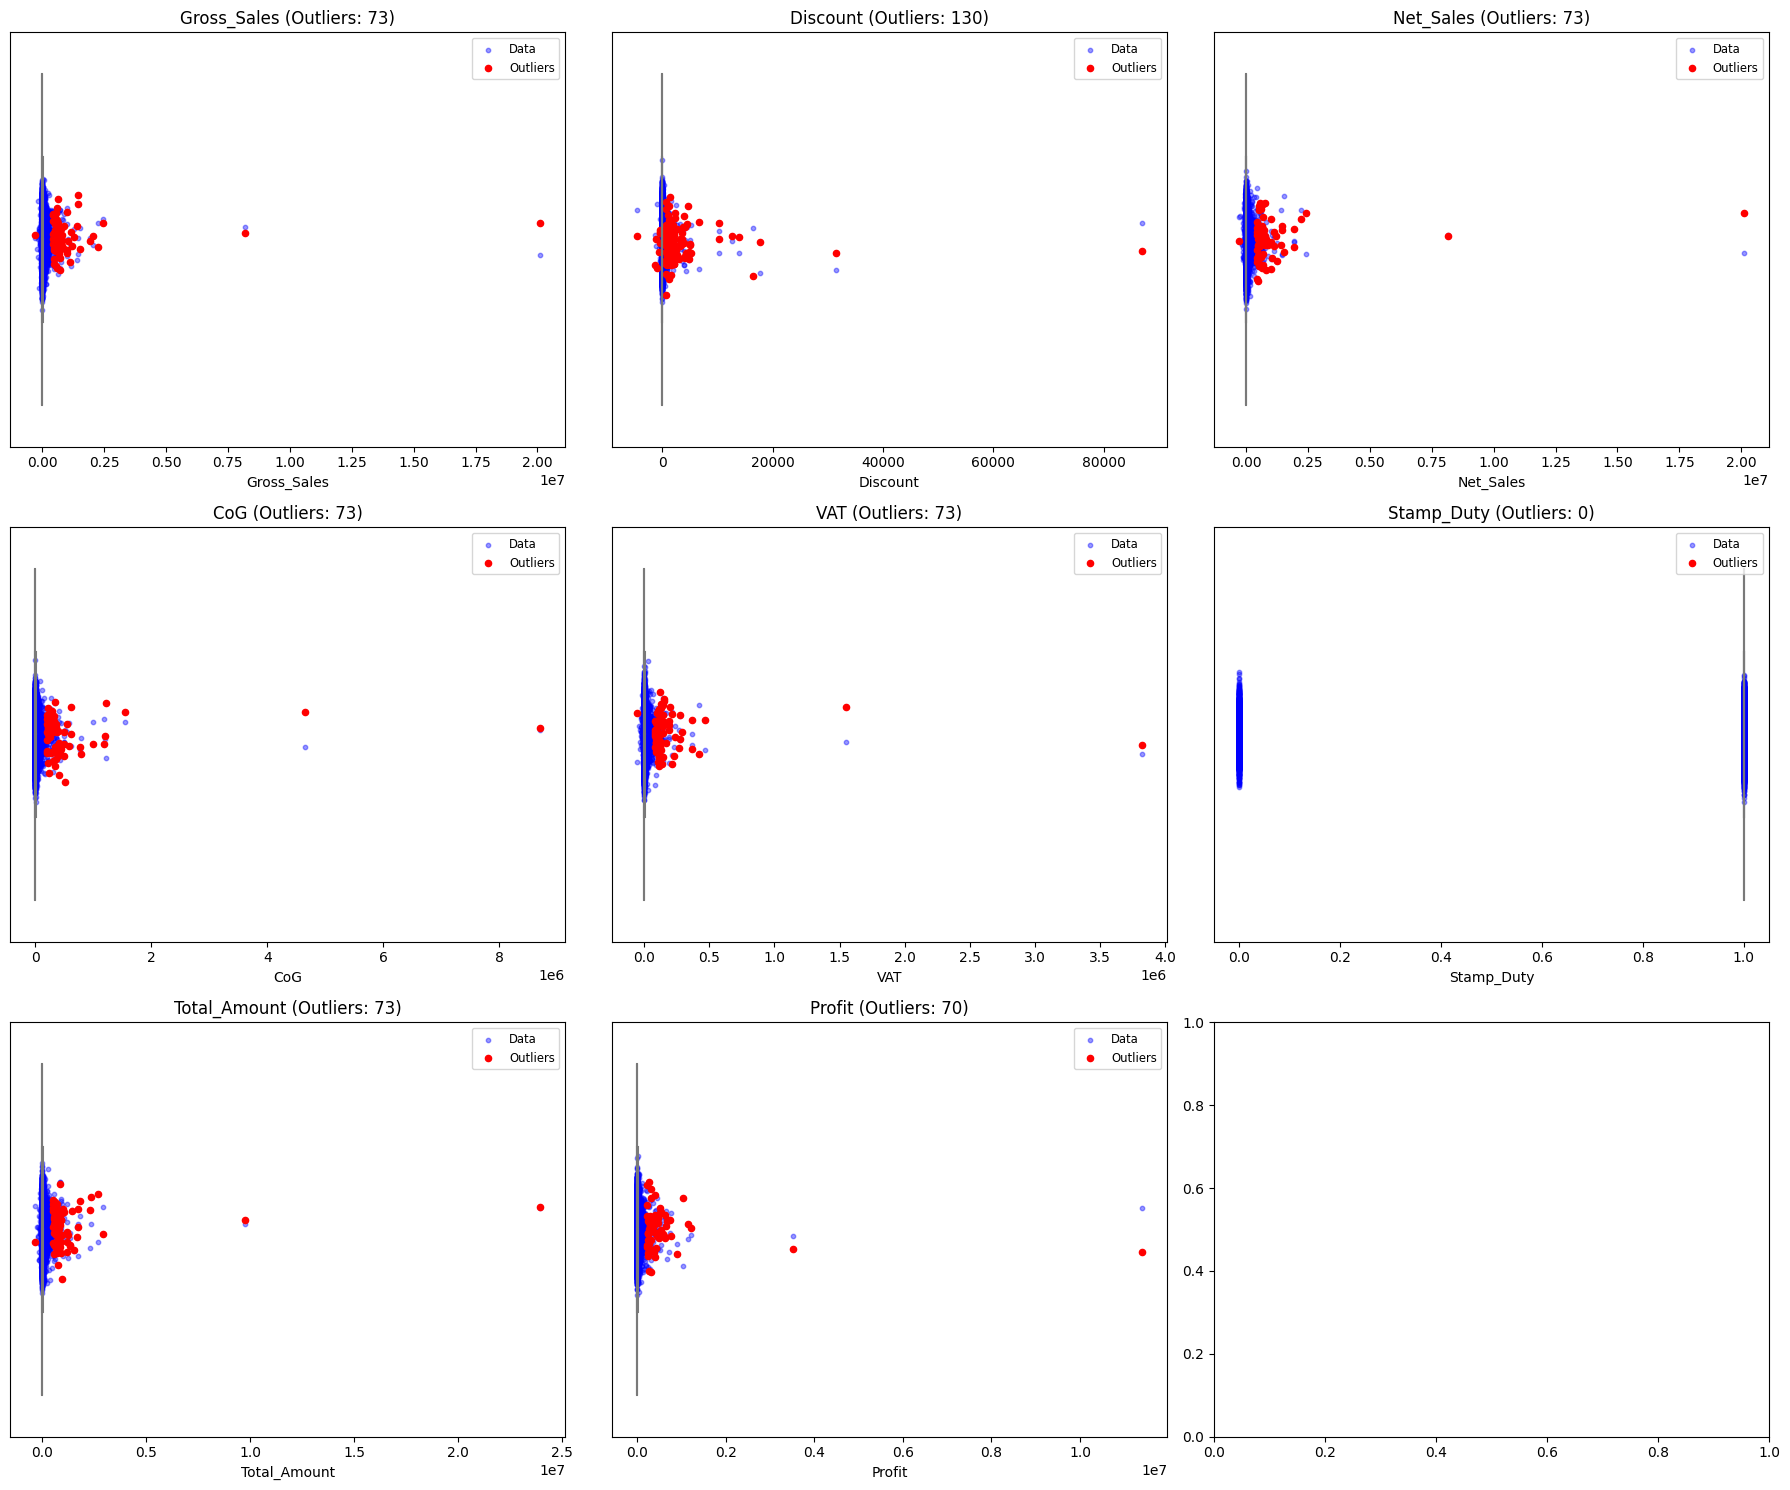

In [27]:
# Detect outliers using the IQR method and visualizes them with combined boxplots and scatter plots for multiple numeric columns.
def detect_outliers_mask(df, column):
    Q1 = df_combined[column].quantile(0.01)
    Q3 = df_combined[column].quantile(0.99)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df_combined[column] < lower_bound) | (df_combined[column] > upper_bound)

# Set up the plot grid size (3 rows x 3 cols for 9 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
num_cols = ['Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Profit']
for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Detect outliers mask
    outlier_mask = detect_outliers_mask(df_combined, col)
    
    # Boxplot
    sns.boxplot(x=df_combined[col], ax=ax, color='lightblue', fliersize=0)  # fliersize=0 hides default outliers
    
    # Scatter plot of all points (jitter y to avoid overlap)
    y_all = np.random.normal(0, 0.04, size=len(df_combined))  # jitter y around 0 for scatter
    ax.scatter(df_combined[col], y_all, alpha=0.4, color='blue', s=10, label='Data')
    
    # Scatter plot of outliers in red
    y_outliers = np.random.normal(0, 0.04, size=outlier_mask.sum())
    ax.scatter(df_combined.loc[outlier_mask, col], y_outliers, color='red', s=20, label='Outliers')
    
    ax.set_yticks([])  # Hide y-axis ticks because y is jitter only
    ax.set_title(f'{col} (Outliers: {outlier_mask.sum()})')
    ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

<ul>
    <li><strong>Profit Calculation:</strong> Added <code>Profit</code> column as <code>Net_Sales - CoG</code>.  
        Profit for returned transactions (<code>Client_Type = 'Return'</code>) is set to 0.</li>
    <li><strong>Payment Method:</strong> Added <code>Payment_Method</code> column: <em>'Credit'</em> for <code>Client_Type='Credit'</code>, otherwise <em>'Cash'</em>.</li>
    <li><strong>Return Flag:</strong> Added binary <code>Is_Return</code> column: <em>'Yes'</em> if <code>Client_Type='RE'</code>, else <em>'No'</em>.</li>
    <li><strong>Total Amount Recalculation:</strong> Updated <code>Total_Amount</code> as <code>Net_Sales + VAT + Stamp_Duty</code>.</li>
</ul>

#### 6.2 Client Categories Rule-based Classification

In [28]:
df_combined['Client_Type'].value_counts()

Client_Type
OR    20554
IC     3974
RE     1167
CL      777
CR       35
Name: count, dtype: int64

##### create row-level categories

In [29]:
# Apply business rules FIRST
def categorize_client(row):
    if row['Client_Type'] == 'CL':
        return 'Walk-In Client'
    elif row['Client_Type'] == 'OR' and row['Stamp_Duty'] == 0:
        return 'State Organization'
    elif row['Client_Type'] == 'OR' and row['Stamp_Duty'] == 1:
        return 'Private Organization'
    elif row['Client_Type'] == 'IC':
        return 'Insurance Agency'
    else:
        return 'X'  # Credit or Returns

df_combined['Client_Category'] = df_combined.apply(categorize_client, axis=1)

In [30]:
print(df_combined['Client_Category'].value_counts())

Client_Category
Private Organization    17725
Insurance Agency         3974
State Organization       2829
X                        1202
Walk-In Client            777
Name: count, dtype: int64


In [31]:
# Find clients who have 'X' category
clients_with_X = df_combined[df_combined['Client_Category'] == 'X']['Client_ID'].unique()

# Find how many of these clients have also 'Private Organization'
clients_with_categories = df_combined[
    (df_combined['Client_ID'].isin(clients_with_X)) & 
    (df_combined['Client_Category'].isin(['Insurance Agency', 'Private Organization', 'State Organization', 'Walk-In Client']))
]['Client_ID'].nunique()

print(f"Number of clients who have category 'X' and also any of ['Insurance Agency', 'Private Organization', 'State Organization', 'Walk-In Client']:{clients_with_categories}")

Number of clients who have category 'X' and also any of ['Insurance Agency', 'Private Organization', 'State Organization', 'Walk-In Client']:781


##### correct raw-level categories using client-level category resolution

In [32]:
# Compute client-level preferred category
client_categories = df_combined.groupby('Client_ID')['Client_Category'].unique()

def resolve_category(categories):
    categories = list(categories)

    if 'Walk-In Client' in categories:
        return 'Walk-In Client'
    if 'State Organization' in categories:
        return 'State Organization'
    if 'Private Organization' in categories:
        return 'Private Organization'
    if 'Insurance Agency' in categories:
        return 'Insurance Agency'
    return 'X'   # stays X only if no other category

client_final_category = client_categories.apply(resolve_category)

In [33]:
# Map the client-level category back **only for rows where Client_Category == 'X'**
mask_X = df_combined['Client_Category'] == 'X'

# map client-level result for those clients, leave others unchanged
df_combined.loc[mask_X, 'Client_Category'] = (
    df_combined.loc[mask_X, 'Client_ID'].map(client_final_category).fillna('X')
)

In [34]:
print(df_combined['Client_Category'].value_counts())

Client_Category
Private Organization    17948
Insurance Agency         3986
State Organization       3251
Walk-In Client           1316
X                           6
Name: count, dtype: int64


In [35]:
df_combined.head(10)

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,VAT,Stamp_Duty,Total_Amount,Client_Type,Profit,Payment_Method,Is_Return,Client_Category
0,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,3622.61,1.00,22689.99,OR,10814.39,Cash,No,Private Organization
1,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,2752.69,1.00,17241.55,OR,5817.79,Cash,No,Private Organization
2,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,382.97,1.00,2399.62,OR,345.37,Cash,No,Private Organization
3,C1839,RE2300000001,2023-01-01,-433.25,0.00,-433.25,0.00,-82.32,0.00,-515.57,RE,0.00,Cash,Yes,State Organization
4,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,291.02,1.00,1823.71,OR,555.39,Cash,No,Private Organization
5,C2264,OR2300000005,2023-01-01,1746.59,0.00,1746.59,1084.43,331.85,1.00,2079.44,OR,662.16,Cash,No,Private Organization
6,C1565,OR2300000006,2023-01-01,1453.98,16.95,1437.03,836.33,273.04,1.00,1711.07,OR,600.70,Cash,No,Private Organization
7,C1760,OR2300000007,2023-01-02,704.85,0.00,704.85,201.80,133.92,1.00,839.77,OR,503.05,Cash,No,Private Organization
8,C576,OR2300000008,2023-01-02,425.08,0.00,425.08,244.10,80.76,1.00,506.84,OR,180.98,Cash,No,Private Organization
9,C470,RE2300000002,2023-01-02,-4751.30,0.00,-4751.30,0.00,-902.75,0.00,-5654.05,RE,0.00,Cash,Yes,State Organization


<ul>
  <li><strong>Rule-Based Classification (initial labeling):</strong><br>
  Deterministic business rules were applied using <code>Client_Type</code> and <code>Stamp_Duty</code> to label records.<br>
  <strong>Initial distribution:</strong> <em>Private Organization (17,725), Insurance Agency (3,974), State Organization (2,829), X/ambiguous (777), Walk-In Client (1,202)</em>.<br>
  Ambiguous rows labeled "X" (777 records) were flagged for supervised classification.</li>
  
  <li><strong>Client-Level Category Resolution:</strong><br>
  Number of clients who have category 'X' and also any of ['Insurance Agency', 'Private Organization', 'State Organization', 'Walk-In Client']: 781
<br>
  A hierarchical resolution rule was applied at the <strong>client-level</strong>:<br>
  <code>Walk-In Client > State Organization > Private Organization > Insurance Agency > X</code><br>
  This reassigned most "X" records based on the client's definitive category elsewhere in the dataset.</li>
  
  <li><strong>Final Distribution after Resolution:</strong><br>
  <em>Private Organization (17,948), Insurance Agency (3,986), State Organization (3,251), Walk-In Client (1,316), X (6)</em>.<br>
  Only <strong>6 ambiguous records</strong> remained for ML classification.</li>
</ul>

<strong>Conclusion:</strong> The rule-based approach successfully labeled more than <strong>99% of records</strong> deterministically, reducing the ML classification task from potentially thousands of ambiguous records to just 6. This hybrid approach maximizes business rule interpretability while reserving machine learning for true edge cases, achieving both scalability and explainability.


In [36]:
# Save dataframe. Intermediate processing (cleaned but not final)
df_interim = df_combined.copy()
df_interim.to_parquet("../data/interim/data_ready.parquet", index=False)

### 7. Modeling and Prediction

In [37]:
# Load interim
df_merge = pd.read_parquet("../data/interim/data_ready.parquet")

#### 7.1 Model Feature Engineering

In [38]:
df_combined = df_merge.copy()

##### Apply mild capping (0.01,0.99) to outliers

In [39]:
def cap_outliers(df, cols, lower_quantile=0.01, upper_quantile=0.99):
    for col in cols:
        lower = df[col].quantile(lower_quantile)
        upper = df[col].quantile(upper_quantile)
        df[col] = df[col].clip(lower, upper)
    return df

num_cols = ['Gross_Sales', 'Discount', 'Net_Sales','CoG', 'VAT' ,'Total_Amount', 'Profit']

df_combined = cap_outliers(df_combined, num_cols)

In [40]:
df_combined_before_FE = df_combined.copy()

#####  Add features engineering for modeling

In [41]:
# Create derived columns for analysis
df_combined['Year'] = df_combined['Date'].dt.year
df_combined['Quarter'] = df_combined['Date'].dt.quarter
df_combined['Month'] = df_combined['Date'].dt.month
df_combined['Day'] = df_combined['Date'].dt.day
# 'Weekday' column (Day of the week, 0 = Monday, 6 = Sunday)
df_combined['Weekday'] = df_combined['Date'].dt.weekday

# End of month / quarter
df_combined['Is_Month_End'] = df_combined['Date'].dt.is_month_end.astype(int)
df_combined['Is_Quarter_End'] = df_combined['Date'].dt.is_quarter_end.astype(int)
# Weekday flags
df_combined['Is_Weekend'] = (df_combined['Weekday'] >= 5).astype(int)

# Profit margin ratio: profit earned per unit of net sales
df_combined['Profit_Margin'] = df_combined['Profit'] / df_combined['Net_Sales']
# Discount rate: fraction of gross sales discounted
df_combined['Discount_Rate'] = df_combined['Discount'] / df_combined['Gross_Sales']  
# VAT rate: tax amount as a fraction of gross sales
df_combined['VAT_Rate'] = df_combined['VAT'] / df_combined['Gross_Sales'] 

# Ratio of net sales to gross sales, indicating the proportion of sales considered 'net'
df_combined['Net_to_Gross'] = df_combined['Net_Sales'] / df_combined['Gross_Sales']
# Ratio of total amount to gross sales, showing overall transaction value as a fraction of gross sales
df_combined['Total_to_Gross'] = df_combined['Total_Amount'] / df_combined['Gross_Sales']
# Cost of Goods sold as a fraction of net sales, indicating the cost efficiency relative to net sales
df_combined['CoG_to_Net'] = df_combined['CoG'] / df_combined['Net_Sales'] 

df_combined.head()

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,VAT,Stamp_Duty,Total_Amount,Client_Type,Profit,Payment_Method,Is_Return,Client_Category,Year,Quarter,Month,Day,Weekday,Is_Month_End,Is_Quarter_End,Is_Weekend,Profit_Margin,Discount_Rate,VAT_Rate,Net_to_Gross,Total_to_Gross,CoG_to_Net
0,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,3622.61,1.00,22689.99,OR,10814.39,Cash,No,Private Organization,2023,1,1,1,6,0,0,1,0.57,0.00,0.19,1.00,1.19,0.43
1,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,2752.69,1.00,17241.55,OR,5817.79,Cash,No,Private Organization,2023,1,1,1,6,0,0,1,0.40,0.00,0.19,1.00,1.19,0.60
2,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,382.97,1.00,2399.62,OR,345.37,Cash,No,Private Organization,2023,1,1,1,6,0,0,1,0.17,0.00,0.19,1.00,1.19,0.83
3,C1839,RE2300000001,2023-01-01,-433.25,0.00,-433.25,0.00,-82.32,0.00,-515.57,RE,0.00,Cash,Yes,State Organization,2023,1,1,1,6,0,0,1,-0.00,-0.00,0.19,1.00,1.19,-0.00
4,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,291.02,1.00,1823.71,OR,555.39,Cash,No,Private Organization,2023,1,1,1,6,0,0,1,0.36,0.00,0.19,1.00,1.19,0.64


In [42]:
cols = ['Profit_Margin', 'Discount_Rate',  'Net_to_Gross',  'CoG_to_Net', 'VAT_Rate', 'Total_to_Gross']
# , 'Total_to_Gross',
for col in cols:
    df_combined[col] = df_combined[col].replace([np.inf, -np.inf], np.nan)

df_combined.fillna({
    'Profit_Margin': 0,
    'Discount_Rate': 0,
    'VAT_Rate': 0,
    'Net_to_Gross': 0,
    'Total_to_Gross': 0,
    'CoG_to_Net': 0
}, inplace=True)

In [43]:
# Sort by client and date
df_combined = df_combined.sort_values(['Client_ID', 'Date']).copy()

# Number of past transactions per client (up to this invoice)
df_combined['Client_Past_Transactions'] = df_combined.groupby('Client_ID').cumcount()

# Cumulative sums (exclude current invoice to avoid leakage)
df_combined['Client_Cum_Sales'] = df_combined.groupby('Client_ID')['Net_Sales'].cumsum() - df_combined['Net_Sales']
df_combined['Client_Cum_Profit'] = df_combined.groupby('Client_ID')['Profit'].cumsum() - df_combined['Profit']
df_combined['Client_Cum_Discount'] = df_combined.groupby('Client_ID')['Discount'].cumsum() - df_combined['Discount']

# Average past values (avoid division by zero)
df_combined['Client_Avg_Past_Profit'] = (
    df_combined['Client_Cum_Profit'] / df_combined['Client_Past_Transactions']
).fillna(0)

df_combined['Client_Avg_Past_Discount'] = (
    df_combined['Client_Cum_Discount'] / df_combined['Client_Past_Transactions']
).fillna(0)

df_combined['Client_Total_Past_Sales'] = df_combined['Client_Cum_Sales']

# Drop helper columns if desired
df_combined = df_combined.drop(columns=['Client_Cum_Sales','Client_Cum_Profit','Client_Cum_Discount','Client_Past_Transactions'])

In [44]:
# Create a new column that is True (1) if Payment_Method is 'Credit', and False (0) otherwise.
df_combined['Payment_Method_Encoded'] = (df_combined['Payment_Method'] == 'Credit').astype(int)

##### Final Dataset Preparation for Classification

In [45]:
df_combined.head()

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,VAT,Stamp_Duty,Total_Amount,Client_Type,Profit,Payment_Method,Is_Return,Client_Category,Year,Quarter,Month,Day,Weekday,Is_Month_End,Is_Quarter_End,Is_Weekend,Profit_Margin,Discount_Rate,VAT_Rate,Net_to_Gross,Total_to_Gross,CoG_to_Net,Client_Avg_Past_Profit,Client_Avg_Past_Discount,Client_Total_Past_Sales,Payment_Method_Encoded
979,C0,OR2300000743,2023-02-08,147.09,0.00,147.09,41.88,27.95,1.00,176.04,OR,105.21,Cash,No,Private Organization,2023,1,2,8,2,0,0,0,0.72,0.00,0.19,1.00,1.20,0.28,0.00,0.00,0.00,0
5998,C1,OR2300004633,2023-08-30,3301.33,0.00,3301.33,1158.83,627.25,1.00,3929.58,OR,2142.50,Cash,No,Private Organization,2023,3,8,30,2,0,0,0,0.65,0.00,0.19,1.00,1.19,0.35,0.00,0.00,0.00,0
22091,C1,IC2500000525,2025-05-27,133.14,0.00,133.14,38.35,25.30,1.00,159.44,IC,94.79,Cash,No,Insurance Agency,2025,2,5,27,1,0,0,0,0.71,0.00,0.19,1.00,1.20,0.29,2142.50,0.00,3301.33,0
26344,C10,OR2500006120,2025-11-17,3846.25,0.00,3846.25,1313.57,730.79,1.00,4578.04,OR,2532.68,Cash,No,Private Organization,2025,4,11,17,0,0,0,0,0.66,0.00,0.19,1.00,1.19,0.34,0.00,0.00,0.00,0
8023,C100,OR2300006196,2023-11-17,77.10,2.80,74.30,36.34,14.12,1.00,89.42,OR,37.96,Cash,No,Private Organization,2023,4,11,17,4,0,0,0,0.51,0.04,0.18,0.96,1.16,0.49,0.00,0.00,0.00,0


In [46]:
# Drop the rows where Client_Category is 'X'
df_combined_prep = df_combined[df_combined['Client_Category'] != 'X'].copy()

print(df_combined_prep['Client_Category'].value_counts())

Client_Category
Private Organization    17948
Insurance Agency         3986
State Organization       3251
Walk-In Client           1316
Name: count, dtype: int64


##### Data Filtering to keep only valid categories

In [47]:
# Filter clearly labeled rows
valid_categories = [
    'Walk-In Client', 'Private Organization', 'State Organization', 'Insurance Agency'
]

df_labeled = df_combined_prep[df_combined_prep['Client_Category'].isin(valid_categories)].copy()

##### Feature Selection

In [48]:
# Features (including lag aggregates)
feature_cols = [
    
    'Net_Sales', 'Stamp_Duty', 'Profit',
    #'CoG','VAT','Total_Amount', 'Gross_Sales','Discount', 'Profit',
    #'Year','Quarter','Is_Month_End','Is_Quarter_End', 'Day',
    'Month', 'Weekday', 
    #'Profit_Margin',
    'CoG_to_Net', 
    #'Total_to_Gross',
    #'Discount_Rate','VAT_Rate','Net_to_Gross', 'Client_Avg_Past_Discount'
    'Client_Total_Past_Sales','Client_Avg_Past_Profit'
    #'Payment_Method_Encoded'
]

# Encode the target labels
le = LabelEncoder()
df_labeled['Client_Category_Encoded'] = le.fit_transform(df_labeled['Client_Category'])

X = df_labeled[feature_cols]
y = df_labeled['Client_Category_Encoded']

#### Data Quality Analysis

##### Multicollinearity Check (VIF > 10)

In [49]:
#Calculate VIF
def calculate_vif(df):
    """
    Calculate VIF for each feature in the DataFrame.
    """
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Calculate VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) 
                       for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

# Calculate VIF for your features
vif_results = calculate_vif(X)
print("VIF Scores:")
print(vif_results)

# Identify high-VIF features to consider removing
high_vif = vif_results[vif_results['VIF'] > 10]
print(f"\nFeatures with VIF > 10 (consider removing/reviewing):")
print(high_vif)

VIF Scores:
                   Feature   VIF
0                Net_Sales 24.63
2                   Profit 24.44
5               CoG_to_Net  6.14
1               Stamp_Duty  5.19
3                    Month  3.71
6  Client_Total_Past_Sales  2.70
7   Client_Avg_Past_Profit  2.68
4                  Weekday  2.59

Features with VIF > 10 (consider removing/reviewing):
     Feature   VIF
0  Net_Sales 24.63
2     Profit 24.44


##### Correlation Analysis

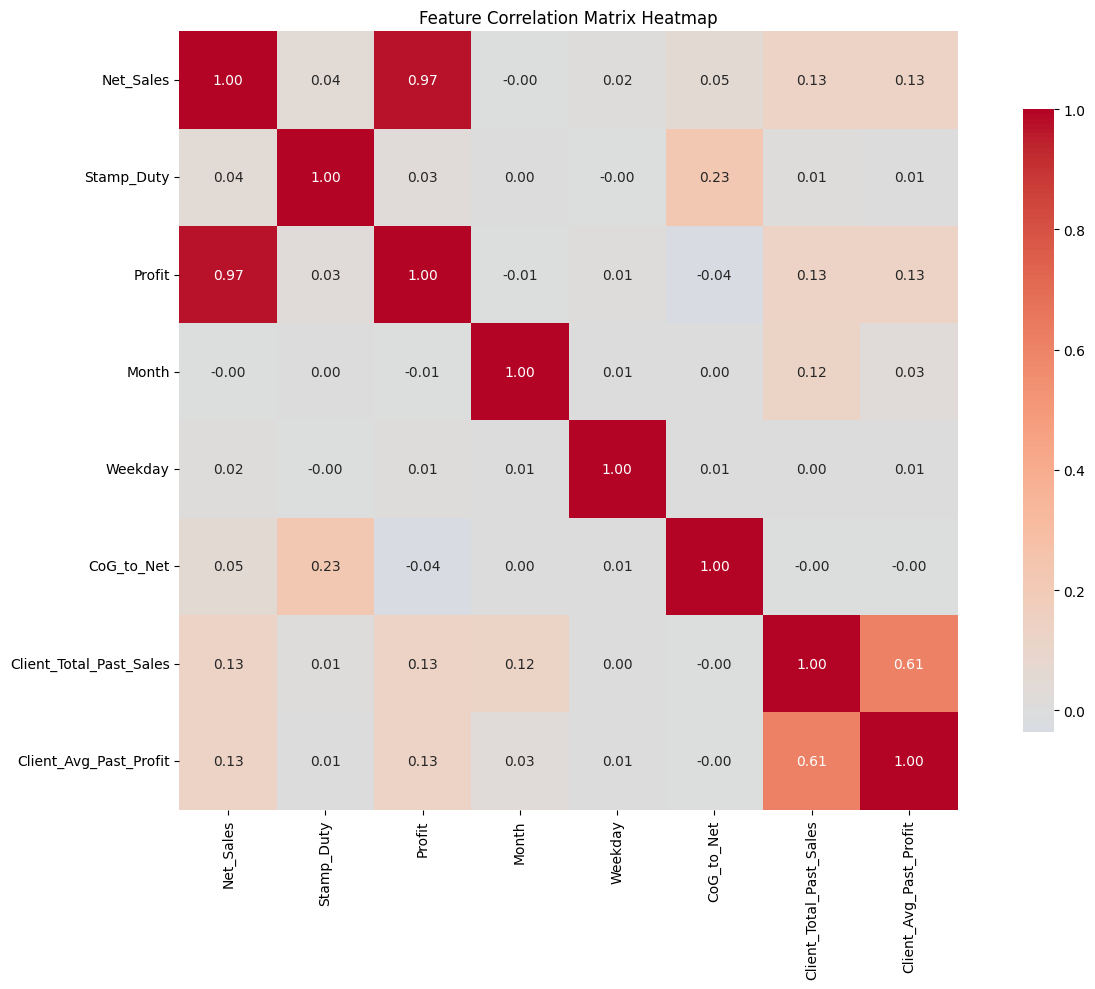


Highly correlated feature pairs (|corr| > 0.8):
Net_Sales - Profit: 0.974


In [50]:
# Calculate correlation matrix
corr_matrix = X.corr()

# Plot a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True,
            cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:  # Threshold of 0.8
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|corr| > 0.8):")
for feat1, feat2, corr in high_corr_pairs:
    print(f"{feat1} - {feat2}: {corr:.3f}")

##### Train/Test Split

In [51]:
# Stratified train/validation split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.2
)

##### Class Imbalance Handling

In [52]:
# Compute sample weights for imbalanced classes
classes = np.unique(y_train)
sample_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
sample_weights_dict = dict(zip(np.unique(y_train), sample_weights))
row_weights = np.array([sample_weights_dict[y] for y in y_train])
# Class weights with category names
class_names = le.inverse_transform(classes)
for cls, weight in zip(class_names, sample_weights):
    print(f"Class: {cls} - Weight: {weight}")

Class: Insurance Agency - Weight: 1.6624843161856964
Class: Private Organization - Weight: 0.36913219111296836
Class: State Organization - Weight: 2.037677816224529
Class: Walk-In Client - Weight: 5.0332383665717


##### **Initial MLflow**

##### Reusable Evaluation function

In [53]:
# Evaluation and mlflow log function
def evaluate_and_log(model, model_name, X_test, y_test, cv_scores, class_names, params=None):
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probability & ROC AUC
    try:
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    except (AttributeError, ValueError):
        roc_auc = None

    # Metrics Calculation
    metrics = {
        "f1_macro": f1_score(y_test, y_pred, average='macro'),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc_macro": roc_auc,
        "f1_weighted": f1_score(y_test, y_pred, average='weighted'),
        "accuracy": accuracy_score(y_test, y_pred),
        "cv_f1_mean": np.mean(cv_scores),
    }

    # Reports
    report = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)

    # MLflow Logging
    with mlflow.start_run(run_name=model_name):
        # Log custom metadata (like version)
        if params is not None:
            mlflow.log_params(params)
        
        # Log model's own internal parameters
        mlflow.log_params(model.get_params() if hasattr(model, 'get_params') else {})
        
        # Log Metrics
        mlflow.log_metrics({k: float(v) for k, v in metrics.items() if v is not None})

        # Ensure output dir exists
        os.makedirs("../output", exist_ok=True)

        # Artifacts
        cm_path = f"../output/{model_name}_cm.csv"
        pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(cm_path)
        mlflow.log_artifact(cm_path)

        report_path = f"../output/{model_name}_report.txt"
        with open(report_path, "w") as f: f.write(report)
        mlflow.log_artifact(report_path)

        # Log Model
        mlflow.sklearn.log_model(model, "model")

    # Local Output
    print(f"\n{'='*20} MODEL: {model_name} {'='*20}")
    print(report)
    print(f"Final Test Macro F1: {metrics['f1_macro']:.4f}")
    print(f"Cross-Validation F1: {metrics['cv_f1_mean']:.4f}")
    
    return metrics

##### Simple wrapper to run + log each model

In [54]:
def run_model_with_mlflow(model, model_name, X_train, y_train, X_test, y_test, 
                         class_names, sample_weight=None, params=None): 
    
    # Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        scoring="f1_macro", 
        cv=cv
    )

    # Final Fit
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)

    # Evaluate + Log
    return evaluate_and_log(
        model=model, 
        model_name=model_name, 
        X_test=X_test, 
        y_test=y_test, 
        cv_scores=cv_scores, 
        class_names=class_names,
        params=params  # Pass params
    )

##### Start MLflow experiment

In [55]:
# Start MLflow experiment
mlflow.set_tracking_uri("http://127.0.0.1:5004")
mlflow.set_experiment("client_classification")

# Verify connection
print(mlflow.get_tracking_uri())  # print: http://127.0.0.1:5004

2025/12/27 14:56:51 INFO mlflow.tracking.fluent: Experiment with name 'client_classification' does not exist. Creating a new experiment.


http://127.0.0.1:5004


#### **🧩 7.2 Baseline Model**

##### **Model 1: Logistic Regression Model**

In [56]:
# BASELINE LOGISTIC REGRESSION
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight='balanced',  # important for imbalanced data
        max_iter=1000, # ensure sufficient iterations for convergence, especially with class weights.
        multi_class='multinomial',
        solver='lbfgs',
        random_state=42
    ))
])

In [57]:
# Logistic Regression
run_model_with_mlflow(
    log_reg,
    "Logistic_Regression_Baseline",
    X_train, y_train,
    X_test, y_test,
    le.classes_
)


==================== MODEL: Logistic_Regression_Baseline ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.22      0.42      0.29       798
Private Organization       0.86      0.55      0.67      3590
  State Organization       0.83      0.85      0.84       650
      Walk-In Client       0.28      0.86      0.43       263

            accuracy                           0.58      5301
           macro avg       0.55      0.67      0.56      5301
        weighted avg       0.73      0.58      0.62      5301

Final Test Macro F1: 0.5568
Cross-Validation F1: 0.5598


{'f1_macro': 0.5568387123711042,
 'mcc': 0.378749134878321,
 'roc_auc_macro': 0.8378191899551115,
 'f1_weighted': 0.622637449739141,
 'accuracy': 0.5842293906810035,
 'cv_f1_mean': 0.5598288459007177}

#### **⚙️ 7.3 Raw Models**

##### **Model 2: Random Forest Raw Model**

In [58]:
# Random Forest
rf_raw = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'  # automatically balances class weights
)

In [59]:
# Random Forest 500 estimator
run_model_with_mlflow(
    rf_raw,
    "Random_Forest_Raw",
    X_train, y_train,
    X_test, y_test,
    le.classes_
)


==================== MODEL: Random_Forest_Raw ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.32      0.01      0.02       798
Private Organization       0.82      0.99      0.89      3590
  State Organization       0.81      0.87      0.84       650
      Walk-In Client       0.62      0.56      0.59       263

            accuracy                           0.80      5301
           macro avg       0.64      0.61      0.59      5301
        weighted avg       0.73      0.80      0.74      5301

Final Test Macro F1: 0.5857
Cross-Validation F1: 0.5845


{'f1_macro': 0.5856879269640021,
 'mcc': 0.5841593629728813,
 'roc_auc_macro': 0.8471380006317127,
 'f1_weighted': 0.7401450952139284,
 'accuracy': 0.8039992454253915,
 'cv_f1_mean': 0.5844972878411434}

##### **Model 3: XGBoost Raw Model**

In [60]:
# XGBoost with sample weights
xgb_raw = XGBClassifier(
    objective='multi:softprob',
    num_class=len(classes),
    eval_metric='mlogloss',
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [61]:
# XGBoost (raw)
run_model_with_mlflow(
    xgb_raw,
    "XGBoost_Raw",
    X_train, y_train,
    X_test, y_test,
    le.classes_,
    sample_weight=row_weights
)


==================== MODEL: XGBoost_Raw ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.24      0.18      0.20       798
Private Organization       0.83      0.86      0.85      3590
  State Organization       0.80      0.86      0.83       650
      Walk-In Client       0.55      0.63      0.59       263

            accuracy                           0.74      5301
           macro avg       0.60      0.63      0.62      5301
        weighted avg       0.72      0.74      0.73      5301

Final Test Macro F1: 0.6152
Cross-Validation F1: 0.5853


{'f1_macro': 0.6152251083177758,
 'mcc': 0.4802300184178167,
 'roc_auc_macro': 0.8359756756112666,
 'f1_weighted': 0.7332837063700369,
 'accuracy': 0.7449537823052255,
 'cv_f1_mean': 0.5853200889502147}

##### **Model 5: LightGBM Raw Model**

In [62]:
# LightGBM
lgbm_raw = LGBMClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'  # supports balanced weights
)

In [63]:
# LightGBM
run_model_with_mlflow(
    lgbm_raw,
    "LightGBM_Raw",
    X_train, y_train,
    X_test, y_test,
    le.classes_,
    sample_weight=row_weights
)


==================== MODEL: LightGBM_Raw ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.20      0.50      0.29       798
Private Organization       0.86      0.52      0.65      3590
  State Organization       0.78      0.88      0.83       650
      Walk-In Client       0.45      0.70      0.54       263

            accuracy                           0.57      5301
           macro avg       0.57      0.65      0.58      5301
        weighted avg       0.73      0.57      0.61      5301

Final Test Macro F1: 0.5762
Cross-Validation F1: 0.6068


{'f1_macro': 0.5762445357168768,
 'mcc': 0.37057811298463644,
 'roc_auc_macro': 0.8371563984411746,
 'f1_weighted': 0.6100337122442715,
 'accuracy': 0.5695151858139974,
 'cv_f1_mean': 0.6067717313260631}

#### **⛏️ 7.4 Optimized Models**

##### **Model 6: XGBoost Optimized Model (with OPTUNA)**

In [64]:
# CV splitter & scorer
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average="macro")

mlflow.set_experiment("client_classification")
# Start a parent run for this Optuna study
with mlflow.start_run(run_name="XGB_Optuna_Study") as parent_run:
    # Optuna Objective
    def objective(trial):
        run_name = f"Trial_{trial.number}"
    
        # Nested run for MLflow logging
        with mlflow.start_run(run_name=run_name, nested=True):
    
            # Hyperparameters
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 80, 900),
                "max_depth": trial.suggest_int("max_depth", 1, 15),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "gamma": trial.suggest_float("gamma", 0.0, 5.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 5.0, log=True),
                "objective": "multi:softprob",
                "num_class": len(classes),
                "eval_metric": "mlogloss",
                "random_state": 42,
                "n_jobs": -1
            }
            
            mlflow.log_params(params)
    
            # XGBoost with pruning callback
            model = XGBClassifier(**params)
    
            # Wrap CV with pruning callback
            from optuna.integration import XGBoostPruningCallback
    
            cv_scores = []
            for train_idx, val_idx in cv.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                w_tr, w_val = row_weights[train_idx], row_weights[val_idx]  # if row_weights is numpy array, this is fine
    
                model.fit(
                    X_tr, y_tr,
                    sample_weight=w_tr,
                    eval_set=[(X_val, y_val)],
                    verbose=False,
                    callbacks=[XGBoostPruningCallback(trial, "validation_0-mlogloss")],
                    early_stopping_rounds=30
                )
    
                preds = model.predict(X_val)
                score = f1_score(y_val, preds, average="macro")
                cv_scores.append(score)
    
            mean_f1 = float(np.mean(cv_scores))
            std_f1 = float(np.std(cv_scores))
    
            mlflow.log_metric("cv_f1_mean", mean_f1)
            mlflow.log_metric("cv_f1_std", std_f1)
    
            return mean_f1
    
    # Create study with TPE sampler & Median pruner
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.MedianPruner()
    )
    
    # Run optimization
    study.optimize(objective, n_trials=40, show_progress_bar=True)
    mlflow.log_param("best_score", study.best_value)
    mlflow.log_params(study.best_params)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-27 15:04:01,458] A new study created in memory with name: no-name-93237dd5-b4de-4b13-bfd0-a642096acf56


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-27 15:06:46,602] Trial 0 finished with value: 0.6116877233888137 and parameters: {'n_estimators': 505, 'max_depth': 10, 'learning_rate': 0.05119957563633086, 'subsample': 0.9408994003361149, 'colsample_bytree': 0.6514709239705059, 'gamma': 0.4908218021734051, 'min_child_weight': 8, 'reg_lambda': 6.781024505683879, 'reg_alpha': 3.2653815004765114}. Best is trial 0 with value: 0.6116877233888137.
[I 2025-12-27 15:08:18,414] Trial 1 finished with value: 0.6118843086140374 and parameters: {'n_estimators': 694, 'max_depth': 9, 'learning_rate': 0.21860300003442862, 'subsample': 0.9278936570704113, 'colsample_bytree': 0.624469933805875, 'gamma': 0.8187066445090224, 'min_child_weight': 6, 'reg_lambda': 5.203442829238068, 'reg_alpha': 0.6721610636667075}. Best is trial 1 with value: 0.6118843086140374.
[I 2025-12-27 15:09:13,801] Trial 2 finished with value: 0.6095062270080994 and parameters: {'n_estimators': 667, 'max_depth': 8, 'learning_rate': 0.20268826440078655, 'subsample': 0.7

In [65]:
# Train final model with best params
best_params_xgb = study.best_params.copy()
best_params_xgb.update({
    "objective": "multi:softprob",
    "num_class": len(classes),
    "eval_metric": "mlogloss",
    "random_state": 42,
    "n_jobs": -1
})
xgb_opt = XGBClassifier(**best_params_xgb)

In [66]:
# XGBoost optimized
run_model_with_mlflow(
    xgb_opt,
    "XGBoost_Optimized",
    X_train, y_train,
    X_test, y_test,
    le.classes_,
    sample_weight=row_weights
)


==================== MODEL: XGBoost_Optimized ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.25      0.38      0.30       798
Private Organization       0.86      0.70      0.77      3590
  State Organization       0.79      0.89      0.84       650
      Walk-In Client       0.45      0.76      0.57       263

            accuracy                           0.68      5301
           macro avg       0.59      0.68      0.62      5301
        weighted avg       0.74      0.68      0.70      5301

Final Test Macro F1: 0.6194
Cross-Validation F1: 0.5990


{'f1_macro': 0.6193804118985935,
 'mcc': 0.44895248623305095,
 'roc_auc_macro': 0.857321233000765,
 'f1_weighted': 0.6988801779864485,
 'accuracy': 0.6772307111865685,
 'cv_f1_mean': 0.5989664580926514}

##### **Model 7: LightGBM Optimized Model (with OPTUNA)**

In [67]:
# CV + scorer
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average="macro")

mlflow.set_experiment("client_classification")

# Optuna objective (LightGBM)
with mlflow.start_run(run_name="LGBM_Optuna_Study") as parent_run:

    def objective(trial):
        run_name = f"Trial_{trial.number}"
    
        with mlflow.start_run(run_name=run_name, nested=True):
    
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 900),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 31, 150),
                "max_depth": trial.suggest_int("max_depth", 4, 12),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 1.0, log=True),
                "objective": "multiclass",
                "num_class": len(classes),
                "random_state": 42,
                "verbosity": -1
            }
    
            mlflow.log_params(params)
    
            fold_scores = []
    
            for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
                w_tr = row_weights[train_idx] if row_weights is not None else None
    
                model = LGBMClassifier(**params)
    
                model.fit(
                    X_tr,
                    y_tr,
                    sample_weight=w_tr,
                    eval_set=[(X_val, y_val)],
                    eval_metric="multi_logloss",
                    early_stopping_rounds=50,
                    verbose=False
                )
    
                preds = model.predict(X_val)
                f1 = f1_score(y_val, preds, average="macro")
                fold_scores.append(f1)
    
                mlflow.log_metric(f"fold_{fold}_f1", float(f1))
    
                # Optuna pruning based on F1
                trial.report(f1, fold)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
    
            mean_f1 = float(np.mean(fold_scores))
            mlflow.log_metric("cv_f1_mean", mean_f1)
    
            return mean_f1

    # Create study + optimize
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),          # TPE
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5) # pruning
    )

    # run optimization (adjust n_trials to your compute/budget)
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    # log study-level results
    mlflow.log_param("optuna_best_value", float(study.best_value))
    mlflow.log_params({f"optuna_best_param__{k}": v for k, v in study.best_params.items()})

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-27 16:46:37,626] A new study created in memory with name: no-name-915ab949-1f48-45cf-86db-ba4f63488c50


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-27 16:47:06,814] Trial 0 finished with value: 0.6136921822491597 and parameters: {'n_estimators': 462, 'learning_rate': 0.08927180304353628, 'num_leaves': 118, 'max_depth': 9, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 12, 'reg_lambda': 5.3994844097874335, 'reg_alpha': 0.3991305878561679}. Best is trial 0 with value: 0.6136921822491597.
[I 2025-12-27 16:48:16,103] Trial 1 finished with value: 0.6169308989961506 and parameters: {'n_estimators': 696, 'learning_rate': 0.010485387725194618, 'num_leaves': 147, 'max_depth': 11, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_samples': 17, 'reg_lambda': 0.4059611610484306, 'reg_alpha': 0.3347776308515933}. Best is trial 1 with value: 0.6169308989961506.
[I 2025-12-27 16:48:31,982] Trial 2 finished with value: 0.6054184700746045 and parameters: {'n_estimators': 502, 'learning_rate': 0.019553708662745254, 'num_leaves': 104, 'max_depth': 5, 'subsampl

In [68]:
# Train final model with best params
best_params_lgbm = study.best_params.copy()
best_params_lgbm.update({
    "objective": "multiclass",
    "num_class": len(classes),
    "random_state": 42,
    "verbosity": -1
})
lgbm_opt = LGBMClassifier(**best_params_lgbm)

In [69]:
# LightGBM optimized
run_model_with_mlflow(
    lgbm_opt,
    "LightGBM_Optimized",
    X_train, y_train,
    X_test, y_test,
    le.classes_,
    sample_weight=row_weights
)


==================== MODEL: LightGBM_Optimized ====================
                      precision    recall  f1-score   support

    Insurance Agency       0.24      0.26      0.25       798
Private Organization       0.84      0.79      0.81      3590
  State Organization       0.80      0.88      0.84       650
      Walk-In Client       0.49      0.71      0.58       263

            accuracy                           0.71      5301
           macro avg       0.59      0.66      0.62      5301
        weighted avg       0.73      0.71      0.72      5301

Final Test Macro F1: 0.6206
Cross-Validation F1: 0.5897


{'f1_macro': 0.6206415081415277,
 'mcc': 0.46043429785226436,
 'roc_auc_macro': 0.8463912098366465,
 'f1_weighted': 0.720203525434075,
 'accuracy': 0.713827579701943,
 'cv_f1_mean': 0.589737505358249}

#### **📌 7.5 Model Evaluation and Selection**

##### **📈 7.5.1 Evaluation Summary**

<li><strong>Models trained & evaluated:</strong></li>

<table border="1" cellpadding="8" cellspacing="0"> 
    <thead> 
        <tr> 
            <th rowspan="2">Model (code name)</th> 
            <th colspan="4">Recall by Class</th>
            <th colspan="4">Overall Metrics</th>
            <th rowspan="2">Short Note</th>
        </tr>
        <tr>
            <th>Ins. Agency</th>
            <th>Private Org.</th>
            <th>State Org.</th>
            <th>Walk-In</th>
            <th>F1 (macro)</th>
            <th>MCC</th>
            <th>ROC-AUC</th>
            <th>F1 (weighted)</th>
        </tr>
    </thead> 
    <tbody>
        <tr>
            <td><strong>Logistic Regression<br><code>log_reg</code></strong></td>
            <td>0.42</td>
            <td>0.55</td>
            <td>0.85</td>
            <td>0.86</td>
            <td>0.5568</td>
            <td>0.3787</td>
            <td>0.8378</td>
            <td>0.6226</td>
            <td>Baseline model, high minority recall but poor precision and low majority performance.</td>
        </tr>
        <tr>
            <td><strong>Random Forest Raw<br><code>rf_raw</code></strong></td>
            <td>0.01</td>
            <td>0.99</td>
            <td>0.87</td>
            <td>0.56</td>
            <td>0.5857</td>
            <td>0.5842</td>
            <td>0.8471</td>
            <td>0.7401</td>
            <td>Terrible for Insurance Agency (recall 0.01), overfits to majority class.</td>
        </tr>
        <tr>
            <td><strong>XGBoost Raw<br><code>xgb_raw</code></strong></td>
            <td>0.18</td>
            <td>0.86</td>
            <td>0.86</td>
            <td>0.63</td>
            <td>0.6152</td>
            <td>0.4802</td>
            <td>0.8360</td>
            <td>0.7333</td>
            <td>Balanced overall but weak Insurance Agency recall (0.18).</td>
        </tr>
        <tr>
            <td><strong>LightGBM Raw<br><code>lgbm_raw</code></strong></td>
            <td>0.50</td>
            <td>0.52</td>
            <td>0.88</td>
            <td>0.70</td>
            <td>0.5762</td>
            <td>0.3706</td>
            <td>0.8372</td>
            <td>0.6100</td>
            <td>Good minority recall but poor Private Organization performance.</td>
        </tr>
        <tr style="background-color:#f0f7ff; border: 2px solid #0056b3;">
            <td><strong>XGBoost Optimized<br><code>xgb_opt</code></strong></td>
            <td><strong>0.38</strong></td>
            <td>0.70</td>
            <td><strong>0.89</strong></td>
            <td><strong>0.76</strong></td>
            <td><strong>0.6194</strong></td>
            <td><strong>0.4490</strong></td>
            <td><strong>0.8573</strong></td>
            <td>0.6989</td>
            <td><strong>🏆 BEST BALANCE: Best Walk-In recall (0.76), strong State Org (0.89), highest ROC-AUC (0.8573).</strong></td>
        </tr>
        <tr style="background-color:#f8f8f8;">
            <td><strong>LightGBM Optimized<br><code>lgbm_opt</code></strong></td>
            <td>0.26</td>
            <td>0.79</td>
            <td>0.88</td>
            <td>0.71</td>
            <td>0.6206</td>
            <td>0.4604</td>
            <td>0.8464</td>
            <td>0.7202</td>
            <td>Best macro-F1 (0.6206) but weaker minority recall than XGBoost Optimized.</td>
        </tr>
    </tbody> 
</table>

<ul>
  <li><strong>Chosen Final Model:</strong> <em>XGBoost Optimized (<code>xgb_opt</code>)</em> ⭐<br>
  <strong>Reason:</strong> <strong>XGBoost Optimized</strong> achieves the <strong>best balance for business priorities</strong> with 
  the highest Walk-In Client recall (0.76) and excellent State Organization recall (0.89), while maintaining 
  reasonable Private Organization performance. Although LightGBM Optimized has slightly higher macro-F1 (0.6206), it underperforms 
  on key minority classes that are critical for business objectives.
  </li>
</ul>
<hr>

##### Threshold Optimization

In [75]:
# Simple threshold adjustment for minority classes
def apply_priority_thresholds(model, X, class_names):
    y_proba = model.predict_proba(X)
    
    # These values act as "Dividers"
    # Lower value = Higher Priority (Model chooses this class more easily)
    # Insurance: 0.18, Private: 0.15, State: 0.4, Walk-In: 0.15
    custom_weights = np.array([0.18, 0.15, 0.4, 0.15]) 
    
    # We divide the probability by the weight. 
    # Adjust predictions
    adjusted_proba = y_proba / custom_weights
    
    return np.argmax(adjusted_proba, axis=1)

# Test adjusted predictions
y_pred_adj = apply_priority_thresholds(xgb_opt, X_test, le.classes_)
print(classification_report(y_test, y_pred_adj, target_names=le.classes_))

                      precision    recall  f1-score   support

    Insurance Agency       0.29      0.30      0.30       798
Private Organization       0.86      0.79      0.82      3590
  State Organization       0.84      0.83      0.83       650
      Walk-In Client       0.43      0.81      0.56       263

            accuracy                           0.72      5301
           macro avg       0.60      0.68      0.63      5301
        weighted avg       0.75      0.72      0.73      5301



##### **🏆 7.5.2 Feature Importance & Interpretability (Model Explainability)**

##### SHAP Explainability: bar plot (feature importance)

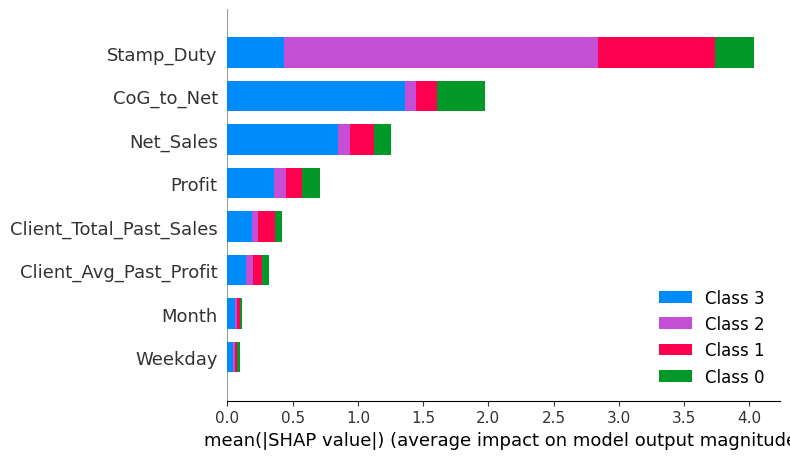

In [76]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_opt) 
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

##### Final Model Saving

In [87]:
client = MlflowClient()

# Get champion model details
model_version = client.get_model_version_by_alias(
    name="client_classifier",
    alias="champion"
)

print(f"Model Version: {model_version.version}")
print(f"Registered: {model_version.creation_timestamp}")

Model Version: 2
Registered: 1766877274268


#### Predict "X" Clients

In [89]:
# Predict Unknown Clients with Priority Thresholding
df_unknown = df_combined[df_combined['Client_Category'] == 'X'].copy()
df_unknown = df_unknown.dropna(subset=feature_cols)
#Define the threhold weights
priority_weights = np.array([0.18, 0.15, 0.4, 0.15])

if not df_unknown.empty:
    X_unknown = df_unknown[feature_cols]
    # Get probabilities
    y_proba_unknown = xgb_opt.predict_proba(X_unknown)
    # Apply priority thresholds
    adjusted_proba = y_proba_unknown / priority_weights
    y_pred_adj = np.argmax(adjusted_proba, axis=1)
    # Decode labels
    df_unknown['Predicted_Client_Category'] = le.inverse_transform(y_pred_adj)
    # Update main dataframe
    df_combined.loc[df_unknown.index, 'Client_Category'] = df_unknown['Predicted_Client_Category']

print("Updated Client Category Counts:")
print(df_combined['Client_Category'].value_counts())

Updated Client Category Counts:
Client_Category
Private Organization    17948
Insurance Agency         3986
State Organization       3253
Walk-In Client           1320
Name: count, dtype: int64


##### Verifying the Dataset

In [92]:
# Ensure not using future information
print("Date range in unknown data:")
print(f"Min: {df_combined['Date'].min()}, Max: {df_combined['Date'].max()}")

Date range in unknown data:
Min: 2023-01-01 00:00:00, Max: 2025-11-23 00:00:00


In [94]:
df_final_combined = df_combined.copy()

In [ ]:
cols_to_drop = [
    'Year', 'Quarter', 'Month', 'Day', 'Weekday', 'Is_Month_End',
    'Is_Quarter_End', 'Is_Weekend', 'Profit_Margin', 'Discount_Rate',
    'VAT_Rate', 'Net_to_Gross', 'Total_to_Gross', 'CoG_to_Net',
    'Client_Avg_Past_Profit', 'Client_Avg_Past_Discount',
    'Client_Total_Past_Sales'
]

df_final_combined = df_final_combined.drop(columns=cols_to_drop)

In [96]:
# Sort by date
df_final_combined = df_final_combined.sort_values('Date', ascending=True).reset_index(drop=True)

df_final_combined.head()

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,Profit,VAT,Stamp_Duty,Total_Amount,Client_Category,Payment_Method,Is_Return,Client_Type
0,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,345.37,382.97,1.00,2399.62,Private Organization,Cash,No,OR
1,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,555.39,291.02,1.00,1823.71,Private Organization,Cash,No,OR
2,C2264,OR2300000005,2023-01-01,1746.59,0.00,1746.59,1084.43,662.16,331.85,1.00,2079.44,Private Organization,Cash,No,OR
3,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,10814.39,3622.61,1.00,22689.99,Private Organization,Cash,No,OR
4,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,5817.79,2752.69,1.00,17241.55,Private Organization,Cash,No,OR


In [97]:
df_final_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26507 entries, 0 to 26506
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Client_ID        26507 non-null  object        
 1   Invoice_Number   26507 non-null  object        
 2   Date             26507 non-null  datetime64[ns]
 3   Gross_Sales      26507 non-null  float64       
 4   Discount         26507 non-null  float64       
 5   Net_Sales        26507 non-null  float64       
 6   CoG              26507 non-null  float64       
 7   Profit           26507 non-null  float64       
 8   VAT              26507 non-null  float64       
 9   Stamp_Duty       26507 non-null  float64       
 10  Total_Amount     26507 non-null  float64       
 11  Client_Category  26507 non-null  object        
 12  Payment_Method   26507 non-null  object        
 13  Is_Return        26507 non-null  object        
 14  Client_Type      26507 non-null  objec

In [98]:
new_order = [
    'Client_ID', 'Invoice_Number', 'Date', 'Gross_Sales', 'Discount', 'Net_Sales', 
    'CoG', 'Profit', 'VAT', 'Stamp_Duty', 'Total_Amount', 
    'Client_Category', 'Payment_Method', 'Is_Return', 'Client_Type'
]

df_final_combined = df_final_combined[new_order]

print(df_final_combined.columns.tolist())

['Client_ID', 'Invoice_Number', 'Date', 'Gross_Sales', 'Discount', 'Net_Sales', 'CoG', 'Profit', 'VAT', 'Stamp_Duty', 'Total_Amount', 'Client_Category', 'Payment_Method', 'Is_Return', 'Client_Type']


In [99]:
# Quick sanity checks
print("\n=== Final Data Validation ===")
print(f"Total records: {len(df_final_combined)}")
print(f"Columns: {len(df_final_combined.columns)}")
print(f"Null values: {df_final_combined.isnull().sum().sum()}")
print(f"Client categories distribution:")
print(df_final_combined['Client_Category'].value_counts())


=== Final Data Validation ===
Total records: 26507
Columns: 15
Null values: 0
Client categories distribution:
Client_Category
Private Organization    17948
Insurance Agency         3986
State Organization       3253
Walk-In Client           1320
Name: count, dtype: int64


In [100]:
df_final_combined.head(20)

,Client_ID,Invoice_Number,Date,Gross_Sales,Discount,Net_Sales,CoG,Profit,VAT,Stamp_Duty,Total_Amount,Client_Category,Payment_Method,Is_Return,Client_Type
0,C812,OR2300000003,2023-01-01,2015.65,0.00,2015.65,1670.28,345.37,382.97,1.00,2399.62,Private Organization,Cash,No,OR
1,C2773,OR2300000004,2023-01-01,1531.69,0.00,1531.69,976.30,555.39,291.02,1.00,1823.71,Private Organization,Cash,No,OR
2,C2264,OR2300000005,2023-01-01,1746.59,0.00,1746.59,1084.43,662.16,331.85,1.00,2079.44,Private Organization,Cash,No,OR
3,C2404,OR2300000001,2023-01-01,19066.38,0.00,19066.38,8251.99,10814.39,3622.61,1.00,22689.99,Private Organization,Cash,No,OR
4,C2592,OR2300000002,2023-01-01,14487.86,0.00,14487.86,8670.07,5817.79,2752.69,1.00,17241.55,Private Organization,Cash,No,OR
5,C1565,OR2300000006,2023-01-01,1453.98,16.95,1437.03,836.33,600.70,273.04,1.00,1711.07,Private Organization,Cash,No,OR
6,C1839,RE2300000001,2023-01-01,-433.25,0.00,-433.25,0.00,0.00,-82.32,0.00,-515.57,State Organization,Cash,Yes,RE
7,C2357,OR2300000013,2023-01-02,2106.97,0.00,2106.97,714.75,1392.22,400.33,1.00,2508.30,Private Organization,Cash,No,OR
8,C2263,IC2300000002,2023-01-02,2355.93,0.00,2355.93,1024.81,1331.12,447.63,1.00,2804.56,Insurance Agency,Cash,No,IC
9,C2422,OR2300000011,2023-01-02,566.68,0.00,566.68,309.39,257.29,107.67,1.00,675.35,Private Organization,Cash,No,OR


In [101]:
#Save the cleaned dataset
df = df_final_combined.copy()
df.to_parquet('../data/processed/data_cleaned.parquet', index=False)
df.to_excel('../data/processed/data_cleaned.xlsx', index=False)
df.to_csv('../data/processed/data_cleaned.csv', index=False)

<hr>
<h4>📝 Data Cleaning and Feature Engineering Summary</h4>

<p>This notebook covers the end-to-end cleaning, validation, and feature engineering of the sales datasets (2023–2025) prior to client categorization and model training. The main steps included:</p>

<ul>
    <li><strong>Data Inspection:</strong> Initial exploration identified column types, missing values, duplicates, and negative values in the Net_Sales column. The unified dataset has <strong>26,507 rows × 11 columns</strong>.</li>
    <li><strong>Missing Data Handling:</strong> Missing values in <code>Discount</code>, <code>CoG</code>, <code>VAT</code>, and <code>Stamp_Duty</code> were replaced with 0. No duplicate rows were found.</li>
    <li><strong>Data Validation:</strong> Net_Sales values were validated to match <code>Gross_Sales − Discount</code>, ensuring consistency.</li>
    <li><strong>Feature Engineering:</strong> New columns were created to enhance analytical power: 
        <ul>
            <li><code>Profit</code>: Net_Sales − CoG (0 for returns)</li>
            <li><code>Payment_Method</code>: 'Credit' for credit clients, otherwise 'Cash'</li>
            <li><code>Is_Return</code>: Binary flag indicating return transactions</li>
            <li><code>Total_Amount</code>: recalculated as Net_Sales + VAT + Stamp_Duty</li>
        </ul>
    </li>
    <li><strong>Column Renaming:</strong> Columns were renamed to clear, consistent English names for analysis and modeling.</li>
</ul>

<h4>📋 Column Descriptions</h4>
<table border="1" cellpadding="6" cellspacing="0">
    <thead>
        <tr>
            <th>Column Name</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr><td>Client_ID</td><td>Unique identifier for each client or transaction.</td></tr>
        <tr><td>Invoice_Number</td><td>Invoice reference number for the transaction.</td></tr>
        <tr><td>Date</td><td>Date of the transaction (datetime format).</td></tr>
        <tr><td>Gross_Sales</td><td>Total sales amount before discounts.</td></tr>
        <tr><td>Discount</td><td>Discount applied to the transaction (0 if missing).</td></tr>
        <tr><td>Net_Sales</td><td>Actual sales after discount (Gross_Sales − Discount).</td></tr>
        <tr><td>CoG</td><td>Cost of Goods Sold; the cost to acquire or produce the sold products (0 if missing).</td></tr>
        <tr><td>VAT</td><td>Value Added Tax applied (0 if missing).</td></tr>
        <tr><td>Stamp_Duty</td><td>Transaction stamp duty, normalized by dividing by 1,000.</td></tr>
        <tr><td>Total_Amount</td><td>Total transaction amount: Net_Sales + VAT + Stamp_Duty.</td></tr>
        <tr><td>Client_Type</td><td>Type of client or transaction category (e.g., Org, Agenc, Client, Return, Credit).</td></tr>
        <tr><td>Profit</td><td>Profit amount for the transaction (Net_Sales − CoG; 0 for returns).</td></tr>
        <tr><td>Payment_Method</td><td>Payment method classification: 'Credit' or 'Cash'.</td></tr>
        <tr><td>Is_Return</td><td>Binary flag indicating if the transaction is a return ('Yes'/'No').</td></tr>
    </tbody>
</table>
<hr>
